In [3]:
%pip install earthengine-api geemap

Note: you may need to restart the kernel to use updated packages.


In [7]:
%pip install rasterio numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 25.4 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [rasterio]3/4 [rasterio]
Note: you may need to restart the kernel to use updated packages.


In [4]:
import ee
import geemap

# Esto abrirá una pestaña en tu navegador para pedirte permisos
ee.Authenticate()

# Inicializa la API (A veces te pedirá que pongas el ID de tu proyecto de Google Cloud)
# Si te da error sin el proyecto, usa: ee.Initialize(project='tu-id-de-proyecto')
ee.Initialize()

print("¡Google Earth Engine configurado correctamente!")

/home/mateo/miniconda3/envs/vision_computacional/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


Abriendo en la sesión del explorador existente.

Successfully saved authorization token.
¡Google Earth Engine configurado correctamente!


In [15]:
# 1. Definir la zona de interés (Bounding Box de Galápagos)
galapagos_roi = ee.Geometry.Rectangle([-92.0, -1.5, -89.0, 1.0])

# 2. Llamar al dataset de MODIS Aqua apuntando al histórico El Niño (2015-2016)
dataset = ee.ImageCollection('NASA/OCEANDATA/MODIS-Aqua/L3SMI') \
            .filterBounds(galapagos_roi) \
            .filterDate('2016-05-01', '2016-05-31')

# 3. Calcular la media de todo el mes
imagen_mayo = dataset.mean().clip(galapagos_roi)

# 4. Seleccionar las bandas físicas
sst_band = imagen_mayo.select('sst')       # Temperatura en °C
chl_band = imagen_mayo.select('chlor_a')   # Clorofila en mg/m^3

# 5. Exportar SST a tu Google Drive
task_sst = ee.batch.Export.image.toDrive(
    image=sst_band,
    description='Galapagos_SST_Mayo2016_Crudo',
    folder='Paper_ICOMTA',
    scale=4000,
    region=galapagos_roi,
    fileFormat='GeoTIFF'
)
task_sst.start()

# 6. Exportar Clorofila a tu Google Drive
task_chl = ee.batch.Export.image.toDrive(
    image=chl_band,
    description='Galapagos_CHL_Mayo2016_Crudo',
    folder='Paper_ICOMTA',
    scale=4000,
    region=galapagos_roi,
    fileFormat='GeoTIFF'
)
task_chl.start()

print("¡Proceso enviado a los servidores de Google!")

¡Proceso enviado a los servidores de Google!


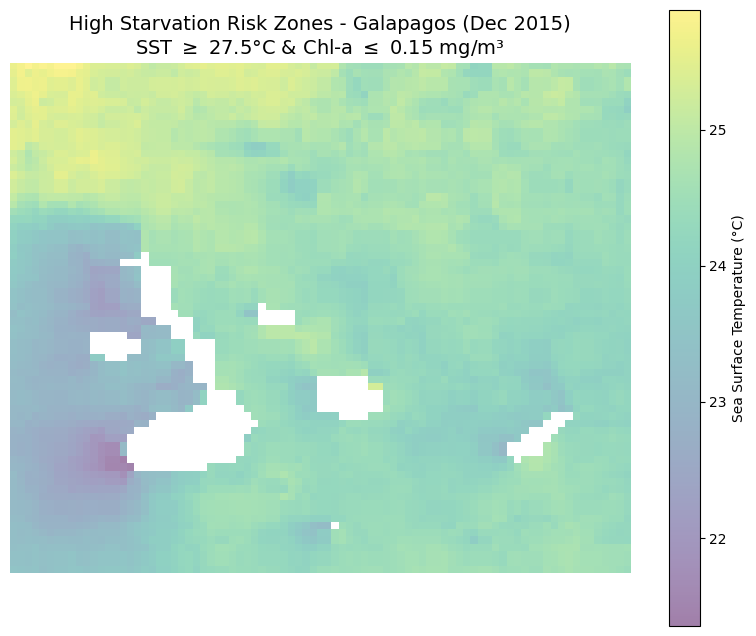

Total Affected Area: 0.00%


In [16]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar las bandas físicas (Ignorando posibles valores nulos/tierra)
with rasterio.open('Galapagos_SST_Mayo2016_Crudo.tif') as src_sst:
    sst_band = src_sst.read(1)
    # Reemplazar valores nulos (tierra/nubes) por un número fuera del rango
    sst_band = np.nan_to_num(sst_band, nan=-999.0) 

with rasterio.open('Galapagos_CHL_Mayo2016_Crudo.tif') as src_chl:
    chl_band = src_chl.read(1)
    chl_band = np.nan_to_num(chl_band, nan=-999.0)

# 2. Definir umbrales físicos (Justificación para tu paper)
# Temperatura letal para afloramiento y escasez crítica de clorofila
UMBRAL_TEMP_ALTA = 27.5 # °C
UMBRAL_CLORO_BAJA = 0.15 # mg/m³

# 3. Álgebra de Bandas (Fusión Lógica)
# Máscara 1: Océano caliente
alerta_termica = (sst_band >= UMBRAL_TEMP_ALTA)

# Máscara 2: Océano sin alimento (asegurando que sea mayor a 0 para no incluir tierra)
alerta_inanicion = (chl_band <= UMBRAL_CLORO_BAJA) & (chl_band > 0)

# Fusión: Intersección espacial del desastre
zona_de_muerte = np.logical_and(alerta_termica, alerta_inanicion)

# 4. Visualización Científica
plt.figure(figsize=(10, 8))

# Mostrar la temperatura de fondo (opcional, para contexto)
plt.imshow(np.where(sst_band > 0, sst_band, np.nan), cmap='viridis', alpha=0.5)
plt.colorbar(label='Sea Surface Temperature (°C)')

# Superponer la "Zona de Muerte" en rojo intenso
plt.imshow(np.where(zona_de_muerte, 1, np.nan), cmap='autumn', interpolation='none')

plt.title('High Starvation Risk Zones - Galapagos (Dec 2015)\nSST $\geq$ 27.5°C & Chl-a $\leq$ 0.15 mg/m³', fontsize=14)
plt.axis('off')
plt.show()

# 5. Cálculo para tu gráfica temporal
area_total_oceano = np.sum(sst_band > 0)
area_afectada = np.sum(zona_de_muerte)
porcentaje = (area_afectada / area_total_oceano) * 100

print(f"Total Affected Area: {porcentaje:.2f}%")

In [17]:
# Extraer solo los píxeles válidos (océano)
sst_validos = sst_band[sst_band > 0]
chl_validos = chl_band[chl_band > 0]

print("=== DIAGNÓSTICO DE TENSORES ===")
print(f"--- TEMPERATURA SUPERFICIAL (SST) ---")
print(f"Máxima: {np.max(sst_validos):.2f} °C")
print(f"Mínima: {np.min(sst_validos):.2f} °C")
print(f"Promedio: {np.mean(sst_validos):.2f} °C")

print(f"\n--- CLOROFILA-A (CHL) ---")
print(f"Máxima: {np.max(chl_validos):.2f} mg/m³")
print(f"Mínima: {np.min(chl_validos):.2f} mg/m³")
print(f"Promedio: {np.mean(chl_validos):.2f} mg/m³")

=== DIAGNÓSTICO DE TENSORES ===
--- TEMPERATURA SUPERFICIAL (SST) ---
Máxima: 25.88 °C
Mínima: 21.35 °C
Promedio: 24.27 °C

--- CLOROFILA-A (CHL) ---
Máxima: 13.16 mg/m³
Mínima: 0.11 mg/m³
Promedio: 0.39 mg/m³


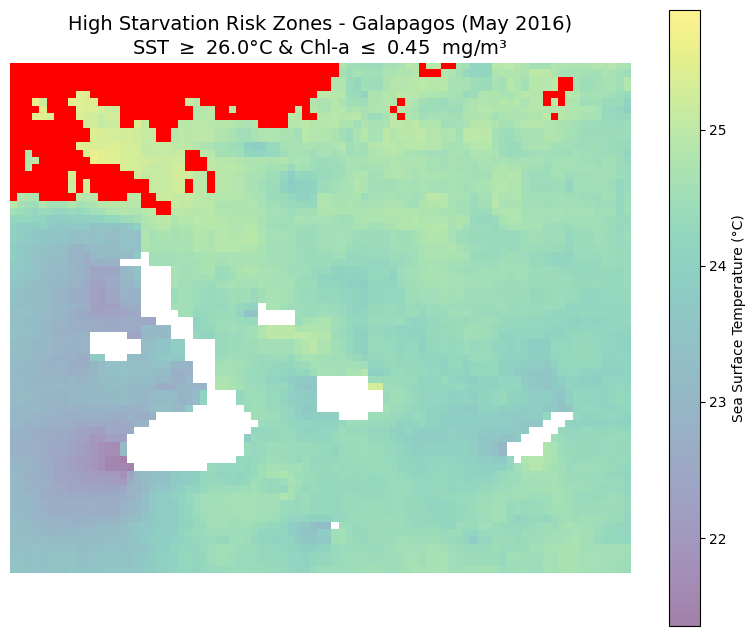

Total Affected Area: 8.77%


In [25]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar las bandas físicas (Ignorando posibles valores nulos/tierra)
with rasterio.open('Galapagos_SST_Mayo2016_Crudo.tif') as src_sst:
    sst_band = src_sst.read(1)
    # Reemplazar valores nulos (tierra/nubes) por un número fuera del rango
    sst_band = np.nan_to_num(sst_band, nan=-999.0) 

with rasterio.open('Galapagos_CHL_Mayo2016_Crudo.tif') as src_chl:
    chl_band = src_chl.read(1)
    chl_band = np.nan_to_num(chl_band, nan=-999.0)

# 2. Definir umbrales físicos (Basado en análisis de distribución estadística)
UMBRAL_TEMP_ALTA = 25.0  # °C (Estrés térmico severo)
UMBRAL_CLORO_BAJA = 0.45 # mg/m³ (Colapso de fitoplancton)

# 3. Álgebra de Bandas (Fusión Lógica)
# Máscara 1: Océano caliente
alerta_termica = (sst_band >= UMBRAL_TEMP_ALTA)

# Máscara 2: Océano sin alimento (asegurando que sea mayor a 0 para no incluir tierra)
alerta_inanicion = (chl_band <= UMBRAL_CLORO_BAJA) & (chl_band > 0)

# Fusión: Intersección espacial del desastre
zona_de_muerte = np.logical_and(alerta_termica, alerta_inanicion)

# 4. Visualización Científica
plt.figure(figsize=(10, 8))

# Mostrar la temperatura de fondo (opcional, para contexto)
plt.imshow(np.where(sst_band > 0, sst_band, np.nan), cmap='viridis', alpha=0.5)
plt.colorbar(label='Sea Surface Temperature (°C)')

# Superponer la "Zona de Muerte" en rojo intenso
plt.imshow(np.where(zona_de_muerte, 1, np.nan), cmap='autumn', interpolation='none')

plt.title('High Starvation Risk Zones - Galapagos (May 2016)\nSST $\geq$ 26.0°C & Chl-a $\leq$ 0.45  mg/m³', fontsize=14)
plt.axis('off')
plt.show()

# 5. Cálculo para tu gráfica temporal
area_total_oceano = np.sum(sst_band > 0)
area_afectada = np.sum(zona_de_muerte)
porcentaje = (area_afectada / area_total_oceano) * 100

print(f"Total Affected Area: {porcentaje:.2f}%")

In [26]:
import ee

# Inicializar Earth Engine (Asegúrate de correr ee.Authenticate() antes si tu sesión expiró)
ee.Initialize()

# 1. Definir la zona de interés (Galápagos) y la colección base
galapagos_roi = ee.Geometry.Rectangle([-92.0, -1.5, -89.0, 1.0])
base_collection = ee.ImageCollection('NASA/OCEANDATA/MODIS-Aqua/L3SMI').filterBounds(galapagos_roi)

# 2. Generar los 3 compuestos temporales promediando los días correspondientes
compuesto_8_dias  = base_collection.filterDate('2015-12-01', '2015-12-09').mean().clip(galapagos_roi)
compuesto_15_dias = base_collection.filterDate('2015-12-01', '2015-12-16').mean().clip(galapagos_roi)
compuesto_30_dias = base_collection.filterDate('2015-12-01', '2015-12-31').mean().clip(galapagos_roi)

# 3. Función auxiliar para exportar a Drive sin repetir código
def exportar_banda(imagen, banda, nombre_archivo):
    task = ee.batch.Export.image.toDrive(
        image=imagen.select(banda),
        description=nombre_archivo,
        folder='Pruebas_Resolucion_Temporal', # Se guardarán en esta nueva carpeta en Drive
        scale=4000,
        region=galapagos_roi,
        fileFormat='GeoTIFF'
    )
    task.start()
    print(f"Tarea enviada a los servidores: {nombre_archivo}")

print("=== INICIANDO EXTRACCIÓN DE PRUEBA ===")

# Exportar Temperatura (SST)
exportar_banda(compuesto_8_dias, 'sst', 'SST_08_Dias_Dic2015')
exportar_banda(compuesto_15_dias, 'sst', 'SST_15_Dias_Dic2015')
exportar_banda(compuesto_30_dias, 'sst', 'SST_30_Dias_Dic2015')

# Exportar Clorofila (CHL)
exportar_banda(compuesto_8_dias, 'chlor_a', 'CHL_08_Dias_Dic2015')
exportar_banda(compuesto_15_dias, 'chlor_a', 'CHL_15_Dias_Dic2015')
exportar_banda(compuesto_30_dias, 'chlor_a', 'CHL_30_Dias_Dic2015')

print("\n¡Listo! Revisa tu Google Drive en unos minutos en la carpeta 'Pruebas_Resolucion_Temporal'.")

=== INICIANDO EXTRACCIÓN DE PRUEBA ===
Tarea enviada a los servidores: SST_08_Dias_Dic2015
Tarea enviada a los servidores: SST_15_Dias_Dic2015
Tarea enviada a los servidores: SST_30_Dias_Dic2015
Tarea enviada a los servidores: CHL_08_Dias_Dic2015
Tarea enviada a los servidores: CHL_15_Dias_Dic2015
Tarea enviada a los servidores: CHL_30_Dias_Dic2015

¡Listo! Revisa tu Google Drive en unos minutos en la carpeta 'Pruebas_Resolucion_Temporal'.


In [27]:
import rasterio
import numpy as np

# Lista exacta de los archivos que exportamos desde Earth Engine
archivos_sst = [
    'SST_08_Dias_Dic2015.tif', 
    'SST_15_Dias_Dic2015.tif', 
    'SST_30_Dias_Dic2015.tif'
]

archivos_chl = [
    'CHL_08_Dias_Dic2015.tif', 
    'CHL_15_Dias_Dic2015.tif', 
    'CHL_30_Dias_Dic2015.tif'
]

def diagnosticar_tensor(lista_archivos, tipo_variable):
    print(f"==================================================")
    print(f"   DIAGNÓSTICO DE TENSORES: {tipo_variable.upper()}")
    print(f"==================================================\n")
    
    for archivo in lista_archivos:
        try:
            with rasterio.open(archivo) as src:
                banda = src.read(1)
                
                # Excluir valores nulos (NaN), infinitos o menores a cero (tierra/nubes)
                # MODIS suele exportar los píxeles sin datos con valores negativos extremos o NaN
                mascara_valida = (banda > 0) & (~np.isnan(banda)) & (~np.isinf(banda))
                datos_validos = banda[mascara_valida]
                
                # Cálculos de área y pérdida de información
                total_pixeles = banda.size
                pixeles_validos = datos_validos.size
                pixeles_perdidos = total_pixeles - pixeles_validos
                porcentaje_perdida = (pixeles_perdidos / total_pixeles) * 100
                
                print(f"--- Archivo: {archivo} ---")
                if pixeles_validos > 0:
                    print(f"  Pico Máximo (Extremo):  {np.max(datos_validos):.2f}")
                    print(f"  Pico Mínimo:            {np.min(datos_validos):.2f}")
                    print(f"  Promedio del Período:   {np.mean(datos_validos):.2f}")
                    # Esta es la métrica clave para decidir:
                    print(f"  Información Oculta por Nubes/Tierra: {porcentaje_perdida:.2f}%\n")
                else:
                    print("  [ERROR] No hay datos válidos. Todo es nube o tierra.\n")
        except FileNotFoundError:
            print(f"  [ERROR] No se encontró el archivo '{archivo}'. Verifica que esté en la carpeta.\n")

# Ejecutar el diagnóstico
diagnosticar_tensor(archivos_sst, "Temperatura (SST) - °C")
diagnosticar_tensor(archivos_chl, "Clorofila-a (CHL) - mg/m³")

   DIAGNÓSTICO DE TENSORES: TEMPERATURA (SST) - °C

--- Archivo: SST_08_Dias_Dic2015.tif ---
  Pico Máximo (Extremo):  27.79
  Pico Mínimo:            21.13
  Promedio del Período:   26.32
  Información Oculta por Nubes/Tierra: 6.18%

--- Archivo: SST_15_Dias_Dic2015.tif ---
  Pico Máximo (Extremo):  27.79
  Pico Mínimo:            21.52
  Promedio del Período:   26.33
  Información Oculta por Nubes/Tierra: 5.61%

--- Archivo: SST_30_Dias_Dic2015.tif ---
  Pico Máximo (Extremo):  27.79
  Pico Mínimo:            24.04
  Promedio del Período:   26.53
  Información Oculta por Nubes/Tierra: 5.21%

   DIAGNÓSTICO DE TENSORES: CLOROFILA-A (CHL) - MG/M³

--- Archivo: CHL_08_Dias_Dic2015.tif ---
  Pico Máximo (Extremo):  1.15
  Pico Mínimo:            0.09
  Promedio del Período:   0.21
  Información Oculta por Nubes/Tierra: 41.95%

--- Archivo: CHL_15_Dias_Dic2015.tif ---
  Pico Máximo (Extremo):  1.15
  Pico Mínimo:            0.08
  Promedio del Período:   0.21
  Información Oculta por Nube

FINAL


In [29]:
import ee
import calendar

# Inicializar Earth Engine
ee.Initialize()

# Definir la zona de interés (Galápagos) y la colección base
galapagos_roi = ee.Geometry.Rectangle([-92.0, -1.5, -89.0, 1.0])
base_collection = ee.ImageCollection('NASA/OCEANDATA/MODIS-Aqua/L3SMI').filterBounds(galapagos_roi)

# Carpeta de destino en Google Drive
CARPETA_DRIVE = 'Dataset_Galapagos_DeepLearning'

def enviar_tareas_exportacion(anio, mes_inicio, mes_fin, tipo_periodo):
    """
    Divide los meses en dos quincenas y envía las tareas a Earth Engine.
    """
    for mes in range(mes_inicio, mes_fin + 1):
        # Encontrar el último día del mes (ej. 28, 30, 31)
        ultimo_dia = calendar.monthrange(anio, mes)[1]
        
        # Definir las ventanas de tiempo: Quincena 1 (Q1) y Quincena 2 (Q2)
        ventanas = [
            (f"{anio}-{mes:02d}-01", f"{anio}-{mes:02d}-15", f"{tipo_periodo}_{anio}_{mes:02d}_Q1"),
            (f"{anio}-{mes:02d}-16", f"{anio}-{mes:02d}-{ultimo_dia}", f"{tipo_periodo}_{anio}_{mes:02d}_Q2")
        ]
        
        for fecha_inicio, fecha_fin, nombre_archivo in ventanas:
            # Calcular el promedio de esa quincena específica
            compuesto = base_collection.filterDate(fecha_inicio, fecha_fin).mean().clip(galapagos_roi)
            
            # Tarea 1: Exportar Temperatura (SST)
            tarea_sst = ee.batch.Export.image.toDrive(
                image=compuesto.select('sst'),
                description=f"SST_{nombre_archivo}",
                folder=CARPETA_DRIVE,
                scale=4000,
                region=galapagos_roi,
                fileFormat='GeoTIFF'
            )
            tarea_sst.start()
            
            # Tarea 2: Exportar Clorofila (CHL)
            tarea_chl = ee.batch.Export.image.toDrive(
                image=compuesto.select('chlor_a'),
                description=f"CHL_{nombre_archivo}",
                folder=CARPETA_DRIVE,
                scale=4000,
                region=galapagos_roi,
                fileFormat='GeoTIFF'
            )
            tarea_chl.start()
            
            print(f"[{nombre_archivo}] Cola enviada: {fecha_inicio} al {fecha_fin}")

print("=== INICIANDO EXTRACCIÓN MASIVA DE DATASET ===")

# 1. PERIODO NORMAL (Control): Enero - Junio 2014
print("\n-> Extrayendo Periodo de CONTROL (2014)...")
enviar_tareas_exportacion(2014, 1, 6, "Control")

# 2. EVENTO EL NIÑO (Anomalía): Septiembre - Diciembre 2015
print("\n-> Extrayendo Periodo de ANOMALÍA (Parte 1: 2015)...")
enviar_tareas_exportacion(2015, 9, 12, "ElNino")

# 3. EVENTO EL NIÑO (Anomalía): Enero - Marzo 2016
print("\n-> Extrayendo Periodo de ANOMALÍA (Parte 2: 2016)...")
enviar_tareas_exportacion(2016, 1, 3, "ElNino")

print("\n¡Proceso finalizado! Se han enviado todas las tareas a los servidores de Google.")
print("Verifica tu Google Drive en unos minutos en la carpeta:", CARPETA_DRIVE)

=== INICIANDO EXTRACCIÓN MASIVA DE DATASET ===

-> Extrayendo Periodo de CONTROL (2014)...
[Control_2014_01_Q1] Cola enviada: 2014-01-01 al 2014-01-15
[Control_2014_01_Q2] Cola enviada: 2014-01-16 al 2014-01-31
[Control_2014_02_Q1] Cola enviada: 2014-02-01 al 2014-02-15
[Control_2014_02_Q2] Cola enviada: 2014-02-16 al 2014-02-28
[Control_2014_03_Q1] Cola enviada: 2014-03-01 al 2014-03-15
[Control_2014_03_Q2] Cola enviada: 2014-03-16 al 2014-03-31
[Control_2014_04_Q1] Cola enviada: 2014-04-01 al 2014-04-15
[Control_2014_04_Q2] Cola enviada: 2014-04-16 al 2014-04-30
[Control_2014_05_Q1] Cola enviada: 2014-05-01 al 2014-05-15
[Control_2014_05_Q2] Cola enviada: 2014-05-16 al 2014-05-31
[Control_2014_06_Q1] Cola enviada: 2014-06-01 al 2014-06-15
[Control_2014_06_Q2] Cola enviada: 2014-06-16 al 2014-06-30

-> Extrayendo Periodo de ANOMALÍA (Parte 1: 2015)...
[ElNino_2015_09_Q1] Cola enviada: 2015-09-01 al 2015-09-15
[ElNino_2015_09_Q2] Cola enviada: 2015-09-16 al 2015-09-30
[ElNino_2015_10_Q

In [42]:
import ee
import calendar

ee.Initialize()
galapagos_roi = ee.Geometry.Rectangle([-92.0, -1.5, -89.0, 1.0])
base_collection = ee.ImageCollection('NASA/OCEANDATA/MODIS-Aqua/L3SMI').filterBounds(galapagos_roi)
CARPETA_DRIVE = 'Dataset_Galapagos_DeepLearning'

def enviar_tareas_exportacion(anio, mes_inicio, mes_fin, tipo_set):
    for mes in range(mes_inicio, mes_fin + 1):
        ultimo_dia = calendar.monthrange(anio, mes)[1]
        ventanas = [
            (f"{anio}-{mes:02d}-01", f"{anio}-{mes:02d}-15", f"{tipo_set}_{anio}_{mes:02d}_Q1"),
            (f"{anio}-{mes:02d}-16", f"{anio}-{mes:02d}-{ultimo_dia}", f"{tipo_set}_{anio}_{mes:02d}_Q2")
        ]
        
        for fecha_inicio, fecha_fin, nombre_archivo in ventanas:
            compuesto = base_collection.filterDate(fecha_inicio, fecha_fin).mean().clip(galapagos_roi)
            
            # Exportar SST y CHL
            for banda, prefijo in [('sst', 'SST'), ('chlor_a', 'CHL')]:
                tarea = ee.batch.Export.image.toDrive(
                    image=compuesto.select(banda),
                    description=f"{prefijo}_{nombre_archivo}",
                    folder=CARPETA_DRIVE, scale=4000, region=galapagos_roi, fileFormat='GeoTIFF'
                )
                tarea.start()
            print(f"[{tipo_set}] Enviado: {nombre_archivo}")

print("=== INICIANDO DESCARGA DE VALIDACIÓN Y TESTEO ===")
# Set de Validación (Mezcla 2018 - 2019)
enviar_tareas_exportacion(2018, 1, 12, "Val")
# Set de Testeo (El Niño Reciente 2023 - Marzo 2024)
enviar_tareas_exportacion(2023, 6, 12, "Test")
enviar_tareas_exportacion(2024, 1, 3, "Test")
print("¡Tareas enviadas a Google Earth Engine!")

=== INICIANDO DESCARGA DE VALIDACIÓN Y TESTEO ===
[Val] Enviado: Val_2018_01_Q1
[Val] Enviado: Val_2018_01_Q2
[Val] Enviado: Val_2018_02_Q1
[Val] Enviado: Val_2018_02_Q2
[Val] Enviado: Val_2018_03_Q1
[Val] Enviado: Val_2018_03_Q2
[Val] Enviado: Val_2018_04_Q1
[Val] Enviado: Val_2018_04_Q2
[Val] Enviado: Val_2018_05_Q1
[Val] Enviado: Val_2018_05_Q2
[Val] Enviado: Val_2018_06_Q1
[Val] Enviado: Val_2018_06_Q2
[Val] Enviado: Val_2018_07_Q1
[Val] Enviado: Val_2018_07_Q2
[Val] Enviado: Val_2018_08_Q1
[Val] Enviado: Val_2018_08_Q2
[Val] Enviado: Val_2018_09_Q1
[Val] Enviado: Val_2018_09_Q2
[Val] Enviado: Val_2018_10_Q1
[Val] Enviado: Val_2018_10_Q2
[Val] Enviado: Val_2018_11_Q1
[Val] Enviado: Val_2018_11_Q2
[Val] Enviado: Val_2018_12_Q1
[Val] Enviado: Val_2018_12_Q2
[Test] Enviado: Test_2023_06_Q1
[Test] Enviado: Test_2023_06_Q2
[Test] Enviado: Test_2023_07_Q1
[Test] Enviado: Test_2023_07_Q2
[Test] Enviado: Test_2023_08_Q1
[Test] Enviado: Test_2023_08_Q2
[Test] Enviado: Test_2023_09_Q1
[Test]

In [43]:
import ee
import calendar

# 1. Inicialización de la API de Earth Engine
ee.Initialize()

# 2. Configuración de área y colección
galapagos_roi = ee.Geometry.Rectangle([-92.0, -1.5, -89.0, 1.0])
base_collection = ee.ImageCollection('NASA/OCEANDATA/MODIS-Aqua/L3SMI').filterBounds(galapagos_roi)
CARPETA_DRIVE = 'Dataset_Galapagos_DeepLearning'

def enviar_tareas_exportacion(anio, mes_inicio, mes_fin, tipo_set):
    """
    Función para automatizar la descarga de quincenas.
    """
    for mes in range(mes_inicio, mes_fin + 1):
        ultimo_dia = calendar.monthrange(anio, mes)[1]
        ventanas = [
            (f"{anio}-{mes:02d}-01", f"{anio}-{mes:02d}-15", f"{tipo_set}_{anio}_{mes:02d}_Q1"),
            (f"{anio}-{mes:02d}-16", f"{anio}-{mes:02d}-{ultimo_dia}", f"{tipo_set}_{anio}_{mes:02d}_Q2")
        ]
        
        for fecha_inicio, fecha_fin, nombre_archivo in ventanas:
            # Crear compuesto quincenal promedio
            compuesto = base_collection.filterDate(fecha_inicio, fecha_fin).mean().clip(galapagos_roi)
            
            # Exportar Temperatura (SST) y Clorofila (CHL)
            for banda, prefijo in [('sst', 'SST'), ('chlor_a', 'CHL')]:
                tarea = ee.batch.Export.image.toDrive(
                    image=compuesto.select(banda),
                    description=f"{prefijo}_{nombre_archivo}",
                    folder=CARPETA_DRIVE, 
                    scale=4000, 
                    region=galapagos_roi, 
                    fileFormat='GeoTIFF'
                )
                tarea.start()
            print(f"[{tipo_set}] Tarea enviada: {nombre_archivo}")

print("=== INICIANDO EXTRACCIÓN PARA TESTEO CIEGO (OPCIÓN 1) ===")

# TESTEO: El Niño Moderado 2009-2010
# Este evento sirve para validar la sensibilidad del modelo ante anomalías no extremas.
print("\n-> Extrayendo datos de 2009 (Septiembre a Diciembre)...")
enviar_tareas_exportacion(2009, 9, 12, "Test")

print("\n-> Extrayendo datos de 2010 (Enero a Marzo)...")
enviar_tareas_exportacion(2010, 1, 3, "Test")

print("\n¡Proceso finalizado! Revisa la pestaña de 'Tasks' en el Code Editor de Earth Engine o tu Google Drive.")

=== INICIANDO EXTRACCIÓN PARA TESTEO CIEGO (OPCIÓN 1) ===

-> Extrayendo datos de 2009 (Septiembre a Diciembre)...
[Test] Tarea enviada: Test_2009_09_Q1
[Test] Tarea enviada: Test_2009_09_Q2
[Test] Tarea enviada: Test_2009_10_Q1
[Test] Tarea enviada: Test_2009_10_Q2
[Test] Tarea enviada: Test_2009_11_Q1
[Test] Tarea enviada: Test_2009_11_Q2
[Test] Tarea enviada: Test_2009_12_Q1
[Test] Tarea enviada: Test_2009_12_Q2

-> Extrayendo datos de 2010 (Enero a Marzo)...
[Test] Tarea enviada: Test_2010_01_Q1
[Test] Tarea enviada: Test_2010_01_Q2
[Test] Tarea enviada: Test_2010_02_Q1
[Test] Tarea enviada: Test_2010_02_Q2
[Test] Tarea enviada: Test_2010_03_Q1
[Test] Tarea enviada: Test_2010_03_Q2

¡Proceso finalizado! Revisa la pestaña de 'Tasks' en el Code Editor de Earth Engine o tu Google Drive.


In [ ]:
import os
import glob
import numpy as np
import rasterio
import cv2

# ==========================================
# 1. CONFIGURACIÓN DE RUTAS Y UMBRALES
# ==========================================
DIRECTORIO_TIFS = 'dataset_galapagos' 
DIRECTORIO_SALIDA = 'ML_Dataset'

# Crear las 3 subcarpetas automáticamente (Train, Val, Test)
subcarpetas = ['train', 'val', 'test']
for sub in subcarpetas:
    os.makedirs(os.path.join(DIRECTORIO_SALIDA, sub, 'images'), exist_ok=True)
    os.makedirs(os.path.join(DIRECTORIO_SALIDA, sub, 'masks'), exist_ok=True)

# Umbrales del modelo físico
TAU_T = 25.5  # °C
TAU_C = 0.15  # mg/m3

# ==========================================
# 2. BÚSQUEDA Y EMPAREJAMIENTO DE ARCHIVOS
# ==========================================
archivos_sst = glob.glob(os.path.join(DIRECTORIO_TIFS, 'SST_*.tif'))
print(f"Se encontraron {len(archivos_sst)} archivos de temperatura para procesar.\n")

# ==========================================
# 3. PROCESAMIENTO POR LOTES Y RUTEO AUTOMÁTICO (ETL)
# ==========================================
for ruta_sst in archivos_sst:
    nombre_base = os.path.basename(ruta_sst).replace('SST_', '').replace('.tif', '')
    ruta_chl = os.path.join(DIRECTORIO_TIFS, f'CHL_{nombre_base}.tif')
    
    if not os.path.exists(ruta_chl):
        print(f"[ADVERTENCIA] No se encontró la pareja CHL para {nombre_base}. Saltando...")
        continue
        
    # LÓGICA DE RUTEO: Determinar a qué subcarpeta va basado en el nombre
    if 'Val_' in nombre_base:
        split_actual = 'val'
    elif 'Test_' in nombre_base:
        split_actual = 'test'
    else:
        # Los archivos que empiezan con Control_ o ElNino_ van para entrenamiento
        split_actual = 'train'
        
    # Establecer rutas de destino dinámicas
    dir_img_actual = os.path.join(DIRECTORIO_SALIDA, split_actual, 'images')
    dir_msk_actual = os.path.join(DIRECTORIO_SALIDA, split_actual, 'masks')

    # Leer los tensores
    with rasterio.open(ruta_sst) as src:
        sst = src.read(1)
    with rasterio.open(ruta_chl) as src:
        chl = src.read(1)
        
    # Crear máscara de datos válidos
    mascara_valida = (sst > 0) & (chl > 0) & (~np.isnan(sst)) & (~np.isnan(chl))
    
    # FASE A: GENERAR EL GROUND TRUTH (MÁSCARA)
    ground_truth = np.zeros_like(sst, dtype=np.uint8)
    ground_truth[(sst >= TAU_T) & (chl <= TAU_C) & mascara_valida] = 255
    
    # FASE B: GENERAR EL INPUT DE LA RED (FALSO COLOR)
    fcc_image = np.zeros((sst.shape[0], sst.shape[1], 3), dtype=np.uint8)
    
    # Canal Rojo: Temperatura
    sst_norm = np.clip((sst - 20.0) / (30.0 - 20.0) * 255, 0, 255)
    fcc_image[:, :, 2] = np.where(mascara_valida, sst_norm, 0) 
    
    # Canal Verde: Clorofila
    chl_norm = np.clip((chl) / 1.0 * 255, 0, 255)
    fcc_image[:, :, 1] = np.where(mascara_valida, chl_norm, 0)
    
    # FASE C: EXPORTAR A DISCO EN LA CARPETA CORRECTA
    nombre_exportacion = f"{nombre_base}.png"
    cv2.imwrite(os.path.join(dir_img_actual, nombre_exportacion), fcc_image)
    cv2.imwrite(os.path.join(dir_msk_actual, nombre_exportacion), ground_truth)
    
    print(f"[OK] Ruteado a '{split_actual.upper()}' y empaquetado: {nombre_exportacion}")

print("\n=== ¡CONSTRUCCIÓN DEL DATASET MULTI-FASE FINALIZADA! ===")
print(f"Los datos están estructurados correctamente en '{DIRECTORIO_SALIDA}' (train, val y test).")

Se encontraron 64 archivos de temperatura para procesar.

[OK] Ruteado a 'TEST' y empaquetado: Test_2009_09_Q1.png
[OK] Ruteado a 'TRAIN' y empaquetado: Control_2014_06_Q1.png
[OK] Ruteado a 'VAL' y empaquetado: Val_2018_09_Q2.png
[OK] Ruteado a 'TRAIN' y empaquetado: ElNino_2015_11_Q2.png
[OK] Ruteado a 'TRAIN' y empaquetado: Control_2014_01_Q2.png
[OK] Ruteado a 'TEST' y empaquetado: Test_2009_11_Q2.png
[OK] Ruteado a 'TEST' y empaquetado: Test_2009_10_Q1.png
[OK] Ruteado a 'TEST' y empaquetado: Test_2009_10_Q2.png
[OK] Ruteado a 'VAL' y empaquetado: Val_2018_03_Q2.png
[OK] Ruteado a 'VAL' y empaquetado: Val_2018_06_Q1.png
[OK] Ruteado a 'TEST' y empaquetado: Test_2010_01_Q1.png
[OK] Ruteado a 'TRAIN' y empaquetado: ElNino_2015_11_Q1.png
[OK] Ruteado a 'VAL' y empaquetado: Val_2018_01_Q2.png
[OK] Ruteado a 'TRAIN' y empaquetado: ElNino_2015_09_Q2.png
[OK] Ruteado a 'VAL' y empaquetado: Val_2018_11_Q2.png
[OK] Ruteado a 'TRAIN' y empaquetado: ElNino_2016_01_Q2.png
[OK] Ruteado a 'TRAI

In [68]:
import os
import glob
import numpy as np
import rasterio

# ==========================================
# DIAGNÓSTICO MASIVO DE TODOS LOS TENSORES
# ==========================================
DIRECTORIO_TIFS = 'dataset_galapagos'

archivos_sst = sorted(glob.glob(os.path.join(DIRECTORIO_TIFS, 'SST_*.tif')))
archivos_chl = sorted(glob.glob(os.path.join(DIRECTORIO_TIFS, 'CHL_*.tif')))

print("=" * 70)
print("DIAGNÓSTICO COMPLETO DEL DATASET GALAPAGOS")
print("=" * 70)

# Almacenar estadísticas globales
stats_globales_sst = {'max': [], 'min': [], 'mean': []}
stats_globales_chl = {'max': [], 'min': [], 'mean': []}

for archivo_sst in archivos_sst:
    nombre_base = os.path.basename(archivo_sst).replace('SST_', '').replace('.tif', '')
    archivo_chl = os.path.join(DIRECTORIO_TIFS, f'CHL_{nombre_base}.tif')
    
    if not os.path.exists(archivo_chl):
        print(f"\n[ADVERTENCIA] No se encontró pareja CHL para {nombre_base}")
        continue
    
    print(f"\n{'─' * 70}")
    print(f"Período: {nombre_base}")
    print(f"{'─' * 70}")
    
    try:
        # Cargar SST
        with rasterio.open(archivo_sst) as src:
            sst_band = src.read(1)
        sst_validos = sst_band[sst_band > 0]
        
        # Cargar CHL
        with rasterio.open(archivo_chl) as src:
            chl_band = src.read(1)
        chl_validos = chl_band[chl_band > 0]
        
        # Estadísticas SST
        if len(sst_validos) > 0:
            sst_max = np.max(sst_validos)
            sst_min = np.min(sst_validos)
            sst_mean = np.mean(sst_validos)
            sst_std = np.std(sst_validos)
            
            stats_globales_sst['max'].append(sst_max)
            stats_globales_sst['min'].append(sst_min)
            stats_globales_sst['mean'].append(sst_mean)
            
            print(f"SST (°C):")
            print(f"  Máxima:     {sst_max:8.2f}")
            print(f"  Mínima:     {sst_min:8.2f}")
            print(f"  Promedio:   {sst_mean:8.2f}")
            print(f"  Desv. Est:  {sst_std:8.2f}")
        
        # Estadísticas CHL
        if len(chl_validos) > 0:
            chl_max = np.max(chl_validos)
            chl_min = np.min(chl_validos)
            chl_mean = np.mean(chl_validos)
            chl_std = np.std(chl_validos)
            
            stats_globales_chl['max'].append(chl_max)
            stats_globales_chl['min'].append(chl_min)
            stats_globales_chl['mean'].append(chl_mean)
            
            print(f"\nCHL (mg/m³):")
            print(f"  Máxima:     {chl_max:8.2f}")
            print(f"  Mínima:     {chl_min:8.2f}")
            print(f"  Promedio:   {chl_mean:8.2f}")
            print(f"  Desv. Est:  {chl_std:8.2f}")
        
        # Información de cobertura
        cobertura_sst = (np.sum(sst_band > 0) / sst_band.size) * 100
        cobertura_chl = (np.sum(chl_band > 0) / chl_band.size) * 100
        print(f"\nCobertura de datos válidos:")
        print(f"  SST: {cobertura_sst:6.2f}%")
        print(f"  CHL: {cobertura_chl:6.2f}%")
        
    except Exception as e:
        print(f"[ERROR] {nombre_base}: {str(e)}")

# Resumen global
print(f"\n\n{'=' * 70}")
print("RESUMEN ESTADÍSTICO GLOBAL")
print(f"{'=' * 70}")

if stats_globales_sst['max']:
    print(f"\nTEMPERATURA SUPERFICIAL (SST):")
    print(f"  Máxima global:    {np.max(stats_globales_sst['max']):8.2f} °C")
    print(f"  Mínima global:    {np.min(stats_globales_sst['min']):8.2f} °C")
    print(f"  Promedio período: {np.mean(stats_globales_sst['mean']):8.2f} °C")

if stats_globales_chl['max']:
    print(f"\nCLOROFILA-A (CHL):")
    print(f"  Máxima global:    {np.max(stats_globales_chl['max']):8.2f} mg/m³")
    print(f"  Mínima global:    {np.min(stats_globales_chl['min']):8.2f} mg/m³")
    print(f"  Promedio período: {np.mean(stats_globales_chl['mean']):8.2f} mg/m³")

print(f"\nTotal de períodos analizados: {len(stats_globales_sst['max'])}")
print(f"{'=' * 70}\n")

DIAGNÓSTICO COMPLETO DEL DATASET GALAPAGOS

──────────────────────────────────────────────────────────────────────
Período: Control_2014_01_Q1
──────────────────────────────────────────────────────────────────────
SST (°C):
  Máxima:        26.14
  Mínima:        22.89
  Promedio:      24.40
  Desv. Est:      0.70

CHL (mg/m³):
  Máxima:         3.96
  Mínima:         0.14
  Promedio:       0.33
  Desv. Est:      0.20

Cobertura de datos válidos:
  SST:  94.71%
  CHL:  92.66%

──────────────────────────────────────────────────────────────────────
Período: Control_2014_01_Q2
──────────────────────────────────────────────────────────────────────
SST (°C):
  Máxima:        26.49
  Mínima:        22.90
  Promedio:      25.09
  Desv. Est:      0.45

CHL (mg/m³):
  Máxima:         1.92
  Mínima:         0.12
  Promedio:       0.31
  Desv. Est:      0.19

Cobertura de datos válidos:
  SST:  94.10%
  CHL:  85.63%

──────────────────────────────────────────────────────────────────────
Período: 

In [31]:
%pip install torch torchvision segmentation-models-pytorch opencv-python matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.5/661.5 kB 3.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 9.9 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 55.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11/11 [segmentation-models-pytorch]on-models-pytorch]
Note: you may need to restart the kernel to use updated packages.


Entrenando en: CUDA
Cargando Datasets...
Imágenes -> Train: 26 | Val: 24 | Test: 14

Inicializando U-Net con backbone ResNet18...

Iniciando entrenamiento...
Epoch 01/40 | Train Loss: 1.6211 | Val Loss: 1.5468 (Mejora: Modelo Guardado)
Epoch 02/40 | Train Loss: 1.5933 | Val Loss: 1.5064 (Mejora: Modelo Guardado)
Epoch 03/40 | Train Loss: 1.5673 | Val Loss: 1.4734 (Mejora: Modelo Guardado)
Epoch 04/40 | Train Loss: 1.5056 | Val Loss: 1.4512 (Mejora: Modelo Guardado)
Epoch 05/40 | Train Loss: 1.4989 | Val Loss: 1.4027 (Mejora: Modelo Guardado)
Epoch 06/40 | Train Loss: 1.4366 | Val Loss: 1.3563 (Mejora: Modelo Guardado)
Epoch 07/40 | Train Loss: 1.4229 | Val Loss: 1.3242 (Mejora: Modelo Guardado)
Epoch 08/40 | Train Loss: 1.3879 | Val Loss: 1.2976 (Mejora: Modelo Guardado)
Epoch 09/40 | Train Loss: 1.3450 | Val Loss: 1.2796 (Mejora: Modelo Guardado)
Epoch 10/40 | Train Loss: 1.3088 | Val Loss: 1.2549 (Mejora: Modelo Guardado)
Epoch 11/40 | Train Loss: 1.3044 | Val Loss: 1.2438 (Mejora: M

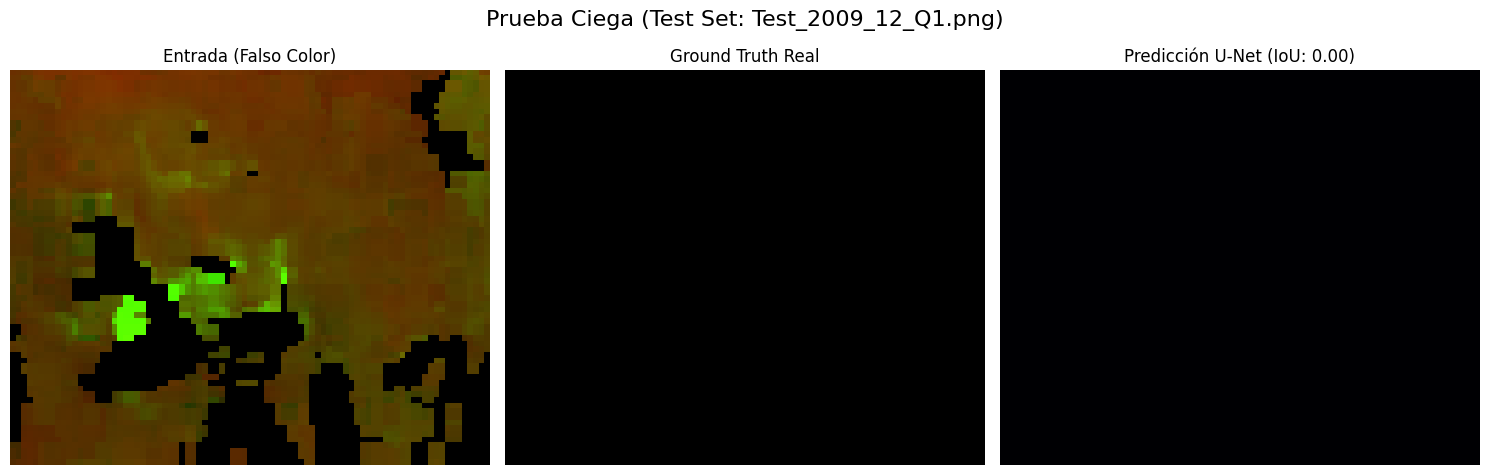

In [9]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIGURACIÓN Y PREPARACIÓN DE DATOS
# ==========================================
# Nuevas rutas basadas en la estructura de 3 fases
DIR_TRAIN_IMG = 'ML_Dataset/train/images'
DIR_TRAIN_MSK = 'ML_Dataset/train/masks'
DIR_VAL_IMG = 'ML_Dataset/val/images'
DIR_VAL_MSK = 'ML_Dataset/val/masks'
DIR_TEST_IMG = 'ML_Dataset/test/images'
DIR_TEST_MSK = 'ML_Dataset/test/masks'

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Entrenando en: {DEVICE.upper()}")

class OceanDataset(Dataset):
    def __init__(self, images_dir, masks_dir):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        # Asegurar que solo lea archivos de imagen
        self.images = [f for f in sorted(os.listdir(images_dir)) if f.endswith(('.png', '.jpg'))]
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_name = self.images[idx]
        
        # Cargar Imagen (Falso Color)
        img_path = os.path.join(self.images_dir, img_name)
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = image / 255.0 
        image = np.transpose(image, (2, 0, 1)) 
        
        # Cargar Máscara (Ground Truth)
        mask_path = os.path.join(self.masks_dir, img_name)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = mask / 255.0 
        mask = np.expand_dims(mask, axis=0) 
        
        return torch.tensor(image, dtype=torch.float32), torch.tensor(mask, dtype=torch.float32)

# Crear los 3 DataLoaders
print("Cargando Datasets...")
dataset_train = OceanDataset(DIR_TRAIN_IMG, DIR_TRAIN_MSK)
dataset_val = OceanDataset(DIR_VAL_IMG, DIR_VAL_MSK)
dataset_test = OceanDataset(DIR_TEST_IMG, DIR_TEST_MSK)

train_loader = DataLoader(dataset_train, batch_size=4, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=4, shuffle=False)
test_loader = DataLoader(dataset_test, batch_size=4, shuffle=False)
print(f"Imágenes -> Train: {len(dataset_train)} | Val: {len(dataset_val)} | Test: {len(dataset_test)}")

# ==========================================
# 2. ARQUITECTURA DEL MODELO U-NET
# ==========================================
print("\nInicializando U-Net con backbone ResNet18...")
model = smp.Unet(
    encoder_name="resnet18", 
    encoder_weights="imagenet", 
    in_channels=3, 
    classes=1      
)
model.to(DEVICE)

# Función de pérdida híbrida y Optimizador
dice_loss = smp.losses.DiceLoss(mode='binary')
bce_loss = torch.nn.BCEWithLogitsLoss()

def criterio_hibrido(prediccion, mascara):
    return dice_loss(prediccion, mascara) + bce_loss(prediccion, mascara)

criterion = criterio_hibrido
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

# ==========================================
# 3. BUCLE DE ENTRENAMIENTO Y VALIDACIÓN
# ==========================================
EPOCHS = 40 
mejor_val_loss = float('inf')
ruta_mejor_modelo = 'mejor_modelo_unet.pth'

print("\nIniciando entrenamiento...")

history = {'train_loss': [], 'val_loss': []}

for epoch in range(EPOCHS):
    # --- FASE DE ENTRENAMIENTO ---
    model.train()
    train_loss = 0
    
    for images, masks in train_loader:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        
    avg_train_loss = train_loss / len(train_loader)
    
    # --- FASE DE VALIDACIÓN ---
    model.eval()
    val_loss = 0
    
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, masks)
            val_loss += loss.item()
            
    avg_val_loss = val_loss / len(val_loader)
    
    # Guardar el mejor modelo si la validación mejora
    if avg_val_loss < mejor_val_loss:
        mejor_val_loss = avg_val_loss
        torch.save(model.state_dict(), ruta_mejor_modelo)
        estado = " (Mejora: Modelo Guardado)"
    else:
        estado = ""

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
        
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}{estado}")

print(f"\n¡Entrenamiento finalizado! El mejor modelo se guardó con Val Loss: {mejor_val_loss:.4f}")

# ==========================================
# 4. TESTEO CIEGO (INFERENCIA EN DATOS NO VISTOS)
# ==========================================
print("\nCargando el mejor modelo para la prueba ciega (Test Set)...")
model.load_state_dict(torch.load(ruta_mejor_modelo))
model.eval() 

# Buscar una imagen del evento de El Niño 2009 en el Test Set
indice_prueba = 0
for i, nombre in enumerate(dataset_test.images):
    if 'Test_2009_12' in nombre or 'Test_2010_01' in nombre: # Buscar el pico de la anomalía
        indice_prueba = i
        break

img_tensor, mask_tensor = dataset_test[indice_prueba]
img_tensor_batch = img_tensor.unsqueeze(0).to(DEVICE) 

with torch.no_grad():
    prediccion = model(img_tensor_batch)
    prediccion = torch.sigmoid(prediccion) 
    prediccion = (prediccion > 0.5).float() 

# Preparar para visualización
img_visual = img_tensor.numpy().transpose(1, 2, 0)
mask_visual = mask_tensor.squeeze().numpy()
pred_visual = prediccion.cpu().squeeze().numpy()

# Calcular métricas básicas en la imagen de prueba
interseccion = np.logical_and(mask_visual == 1, pred_visual == 1).sum()
union = np.logical_or(mask_visual == 1, pred_visual == 1).sum()
iou = interseccion / union if union > 0 else 0.0
print(f"Evaluación visual del Test Set -> IoU de la predicción: {iou:.4f}")

# Dibujar la comparativa final
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'Prueba Ciega (Test Set: {dataset_test.images[indice_prueba]})', fontsize=16)

axes[0].imshow(img_visual)
axes[0].set_title('Entrada (Falso Color)')
axes[0].axis('off')

axes[1].imshow(mask_visual, cmap='gray')
axes[1].set_title('Ground Truth Real')
axes[1].axis('off')

axes[2].imshow(pred_visual, cmap='inferno')
axes[2].set_title(f'Predicción U-Net (IoU: {iou:.2f})')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('unet_blind_test_results.png', dpi=300)
plt.show()

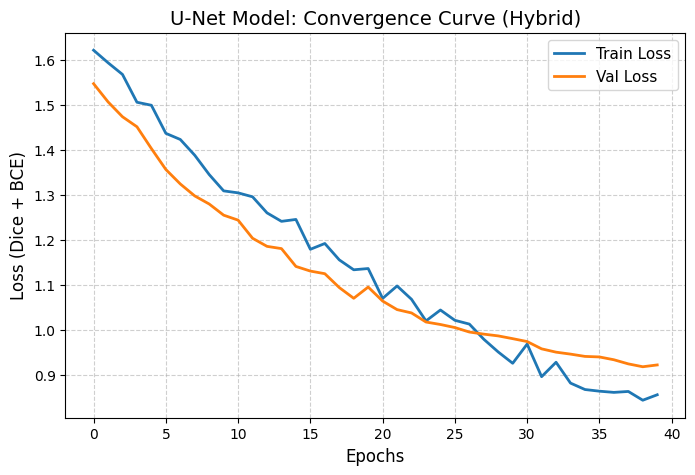

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history['train_loss'], label='Train Loss', color='#1f77b4', linewidth=2)
plt.plot(history['val_loss'], label='Val Loss', color='#ff7f0e', linewidth=2)

plt.title('U-Net Model: Convergence Curve (Hybrid)', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (Dice + BCE)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right', fontsize=11)

# Guardar en alta resolución para LaTeX
plt.savefig('loss_curve.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
import torch
import numpy as np
import cv2
import torch
import numpy as np
import cv2
try:
    from sklearn.metrics import precision_score, recall_score, f1_score
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-learn"])
    from sklearn.metrics import precision_score, recall_score, f1_score
import segmentation_models_pytorch as smp

# ==========================================
# 1. CONFIGURACIÓN Y CARGA
# ==========================================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
RUTA_MODELO = 'mejor_modelo_unet.pth'

print("Cargando modelo para evaluación cuantitativa...")
modelo_eval = smp.Unet(encoder_name="resnet18", encoder_weights=None, in_channels=3, classes=1)
modelo_eval.load_state_dict(torch.load(RUTA_MODELO, map_location=DEVICE))
modelo_eval.to(DEVICE)
modelo_eval.eval()

# Variables para acumular métricas globales
todas_predicciones = []
todas_mascaras = []

print("Evaluando el Blind Test Set...")
with torch.no_grad():
    for images, masks in test_loader: # Asumiendo que test_loader sigue en memoria
        images = images.to(DEVICE)
        
        # Inferencia
        outputs = modelo_eval(images)
        preds = torch.sigmoid(outputs)
        preds = (preds > 0.5).float().cpu().numpy().flatten()
        
        reales = masks.numpy().flatten()
        
        todas_predicciones.extend(preds)
        todas_mascaras.extend(reales)

# ==========================================
# 2. CÁLCULO DE MÉTRICAS ESTÁNDAR
# ==========================================
y_true = np.array(todas_mascaras)
y_pred = np.array(todas_predicciones)

# Solo calcular si hay píxeles de riesgo en el Ground Truth para evitar errores de división por cero
if np.sum(y_true) > 0:
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    # Calcular Dice (que es 2*TP / (2*TP + FP + FN), equivalente al F1 en arreglos binarios)
    dice = f1 
    
    print("\n=== MÉTRICAS DEL TEST CIEGO ===")
    print(f"Precisión: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"Dice:      {dice:.4f}")
else:
    print("El Test Set no tiene píxeles positivos en el Ground Truth. Prueba con el Val Set.")

# ==========================================
# 3. ANÁLISIS MORFOLÓGICO (MUESTRA)
# ==========================================
# Tomamos una imagen que sabemos que tiene anomalías (ej. Val_2018_12_Q2) para el conteo de componentes
img_tensor, mask_tensor = dataset_val[23] # Ajusta el índice si es necesario para agarrar una con manchas
img_tensor_batch = img_tensor.unsqueeze(0).to(DEVICE)

with torch.no_grad():
    pred_morph = modelo_eval(img_tensor_batch)
    pred_morph = (torch.sigmoid(pred_morph) > 0.5).float().cpu().squeeze().numpy().astype(np.uint8)

mask_morph = mask_tensor.squeeze().numpy().astype(np.uint8)

# Conteo de componentes conectados (fragmentación)
num_labels_real, _ = cv2.connectedComponents(mask_morph)
num_labels_pred, _ = cv2.connectedComponents(pred_morph)

print("\n=== ANÁLISIS DE FRAGMENTACIÓN (MUESTRA) ===")
print(f"Componentes en Ground Truth: {num_labels_real - 1}")
print(f"Componentes en Predicción (U-Net):      {num_labels_pred - 1}")
import segmentation_models_pytorch as smp

# ==========================================
# 1. CONFIGURACIÓN Y CARGA
# ==========================================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
RUTA_MODELO = 'mejor_modelo_unet.pth'

print("Cargando modelo para evaluación cuantitativa...")
modelo_eval = smp.Unet(encoder_name="resnet18", encoder_weights=None, in_channels=3, classes=1)
modelo_eval.load_state_dict(torch.load(RUTA_MODELO, map_location=DEVICE))
modelo_eval.to(DEVICE)
modelo_eval.eval()

# Variables para acumular métricas globales
todas_predicciones = []
todas_mascaras = []

print("Evaluando el Blind Test Set...")
with torch.no_grad():
    for images, masks in test_loader: # Asumiendo que test_loader sigue en memoria
        images = images.to(DEVICE)
        
        # Inferencia
        outputs = modelo_eval(images)
        preds = torch.sigmoid(outputs)
        preds = (preds > 0.5).float().cpu().numpy().flatten()
        
        reales = masks.numpy().flatten()
        
        todas_predicciones.extend(preds)
        todas_mascaras.extend(reales)

# ==========================================
# 2. CÁLCULO DE MÉTRICAS ESTÁNDAR
# ==========================================
y_true = np.array(todas_mascaras)
y_pred = np.array(todas_predicciones)

# Solo calcular si hay píxeles de riesgo en el Ground Truth para evitar errores de división por cero
if np.sum(y_true) > 0:
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    # Calcular Dice (que es 2*TP / (2*TP + FP + FN), equivalente al F1 en arreglos binarios)
    dice = f1 
    
    print("\n=== MÉTRICAS DEL TEST CIEGO ===")
    print(f"Precisión: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"Dice:      {dice:.4f}")
else:
    print("El Test Set no tiene píxeles positivos en el Ground Truth. Prueba con el Val Set.")

# ==========================================
# 3. ANÁLISIS MORFOLÓGICO (MUESTRA)
# ==========================================
# Tomamos una imagen que sabemos que tiene anomalías (ej. Val_2018_12_Q2) para el conteo de componentes
img_tensor, mask_tensor = dataset_val[23] # Ajusta el índice si es necesario para agarrar una con manchas
img_tensor_batch = img_tensor.unsqueeze(0).to(DEVICE)

with torch.no_grad():
    pred_morph = modelo_eval(img_tensor_batch)
    pred_morph = (torch.sigmoid(pred_morph) > 0.5).float().cpu().squeeze().numpy().astype(np.uint8)

mask_morph = mask_tensor.squeeze().numpy().astype(np.uint8)

# Conteo de componentes conectados (fragmentación)
num_labels_real, _ = cv2.connectedComponents(mask_morph)
num_labels_pred, _ = cv2.connectedComponents(pred_morph)

print("\n=== ANÁLISIS DE FRAGMENTACIÓN (MUESTRA) ===")
print(f"Componentes en Ground Truth: {num_labels_real - 1}")
print(f"Componentes en Predicción (U-Net):      {num_labels_pred - 1}")

Cargando modelo para evaluación cuantitativa...
Evaluando el Blind Test Set...

=== MÉTRICAS DEL TEST CIEGO ===
Precisión: 0.0813
Recall:    0.4953
F1-Score:  0.1396
Dice:      0.1396

=== ANÁLISIS DE FRAGMENTACIÓN (MUESTRA) ===
Componentes en Ground Truth: 15
Componentes en Predicción (U-Net):      5
Cargando modelo para evaluación cuantitativa...
Evaluando el Blind Test Set...

=== MÉTRICAS DEL TEST CIEGO ===
Precisión: 0.0813
Recall:    0.4953
F1-Score:  0.1396
Dice:      0.1396

=== ANÁLISIS DE FRAGMENTACIÓN (MUESTRA) ===
Componentes en Ground Truth: 15
Componentes en Predicción (U-Net):      5


Cargando el modelo graduado...

Archivos disponibles en el Test Set:
 - Test_2009_09_Q1.png
 - Test_2009_09_Q2.png
 - Test_2009_10_Q1.png
 - Test_2009_10_Q2.png
 - Test_2009_11_Q1.png
 - Test_2009_11_Q2.png
 - Test_2009_12_Q1.png
 - Test_2009_12_Q2.png
 - Test_2010_01_Q1.png
 - Test_2010_01_Q2.png
 - Test_2010_02_Q1.png
 - Test_2010_02_Q2.png
 - Test_2010_03_Q1.png
 - Test_2010_03_Q2.png

Mostrando resultado...


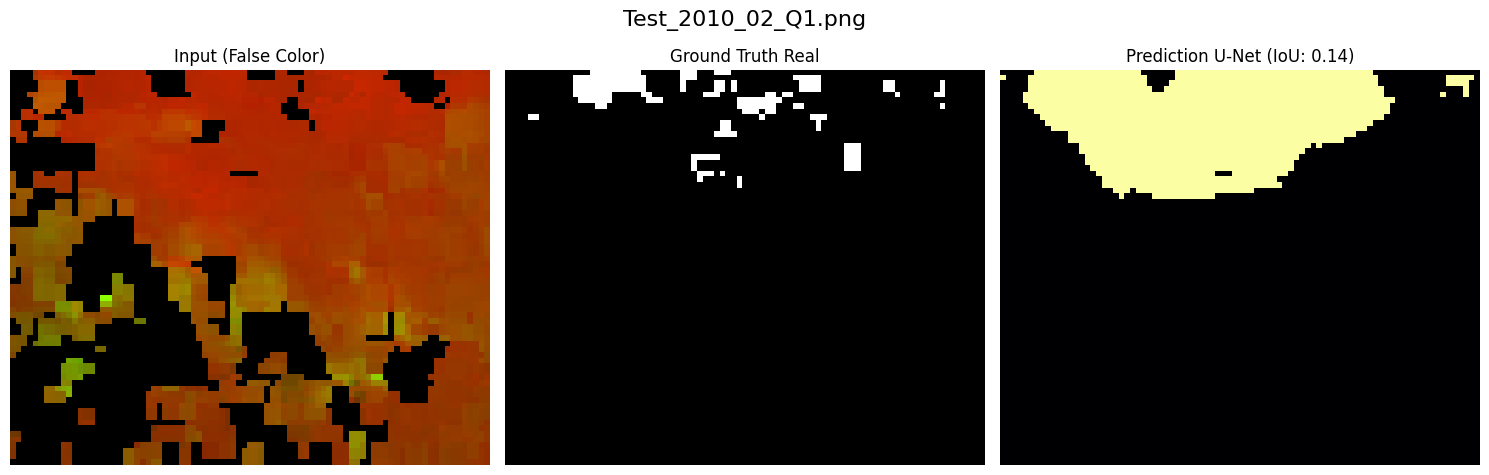

In [12]:
import os
import cv2
import numpy as np
import torch
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIGURACIÓN Y CARGA DEL MODELO
# ==========================================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DIR_TEST_IMG = 'ML_Dataset/test/images'
DIR_TEST_MSK = 'ML_Dataset/test/masks'
RUTA_MODELO = 'mejor_modelo_unet.pth'

print("Cargando el modelo graduado...")
# Inicializar la arquitectura vacía
modelo_eval = smp.Unet(encoder_name="resnet18", encoder_weights=None, in_channels=3, classes=1)
# Cargar los pesos entrenados que guardamos
modelo_eval.load_state_dict(torch.load(RUTA_MODELO, map_location=DEVICE))
modelo_eval.to(DEVICE)
modelo_eval.eval() # Modo evaluación (importante)

# ==========================================
# 2. FUNCIÓN DE TESTEO MANUAL
# ==========================================
def inspeccionar_prediccion(nombre_archivo):
    ruta_img = os.path.join(DIR_TEST_IMG, nombre_archivo)
    ruta_msk = os.path.join(DIR_TEST_MSK, nombre_archivo)
    
    if not os.path.exists(ruta_img):
        print(f"Error: El archivo {nombre_archivo} no existe en la carpeta test/images.")
        return
        
    # Cargar y preparar imagen
    image = cv2.imread(ruta_img)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    img_visual = image.copy() # Para mostrarla luego
    
    image = image / 255.0 
    image = np.transpose(image, (2, 0, 1))
    img_tensor = torch.tensor(image, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    
    # Cargar y preparar Ground Truth
    mask_visual = cv2.imread(ruta_msk, cv2.IMREAD_GRAYSCALE)
    
    # Hacer Inferencia
    with torch.no_grad():
        prediccion = modelo_eval(img_tensor)
        prediccion = torch.sigmoid(prediccion) 
        prediccion = (prediccion > 0.5).float() 
        
    pred_visual = prediccion.cpu().squeeze().numpy()
    
    # Calcular IoU
    interseccion = np.logical_and(mask_visual == 255, pred_visual == 1).sum()
    union = np.logical_or(mask_visual == 255, pred_visual == 1).sum()
    iou = interseccion / union if union > 0 else 1.0 if np.sum(mask_visual) == 0 and np.sum(pred_visual) == 0 else 0.0
    
    # Graficar
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'{nombre_archivo}', fontsize=16)

    axes[0].imshow(img_visual)
    axes[0].set_title('Input (False Color)')
    axes[0].axis('off')

    axes[1].imshow(mask_visual, cmap='gray')
    axes[1].set_title('Ground Truth Real')
    axes[1].axis('off')

    axes[2].imshow(pred_visual, cmap='inferno')
    axes[2].set_title(f'Prediction U-Net (IoU: {iou:.2f})')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# ==========================================
# 3. LISTAR ARCHIVOS DISPONIBLES Y PROBAR
# ==========================================
archivos_test = sorted([f for f in os.listdir(DIR_TEST_IMG) if f.endswith('.png')])
print("\nArchivos disponibles en el Test Set:")
for f in archivos_test:
    print(f" - {f}")

# ¡Cambia el nombre aquí para probar diferentes quincenas!
print("\nMostrando resultado...")
#inspeccionar_prediccion(archivos_test[0]) 
# También puedes llamarla directamente así:
inspeccionar_prediccion('Test_2010_02_Q1.png')

Generating images for the paper...


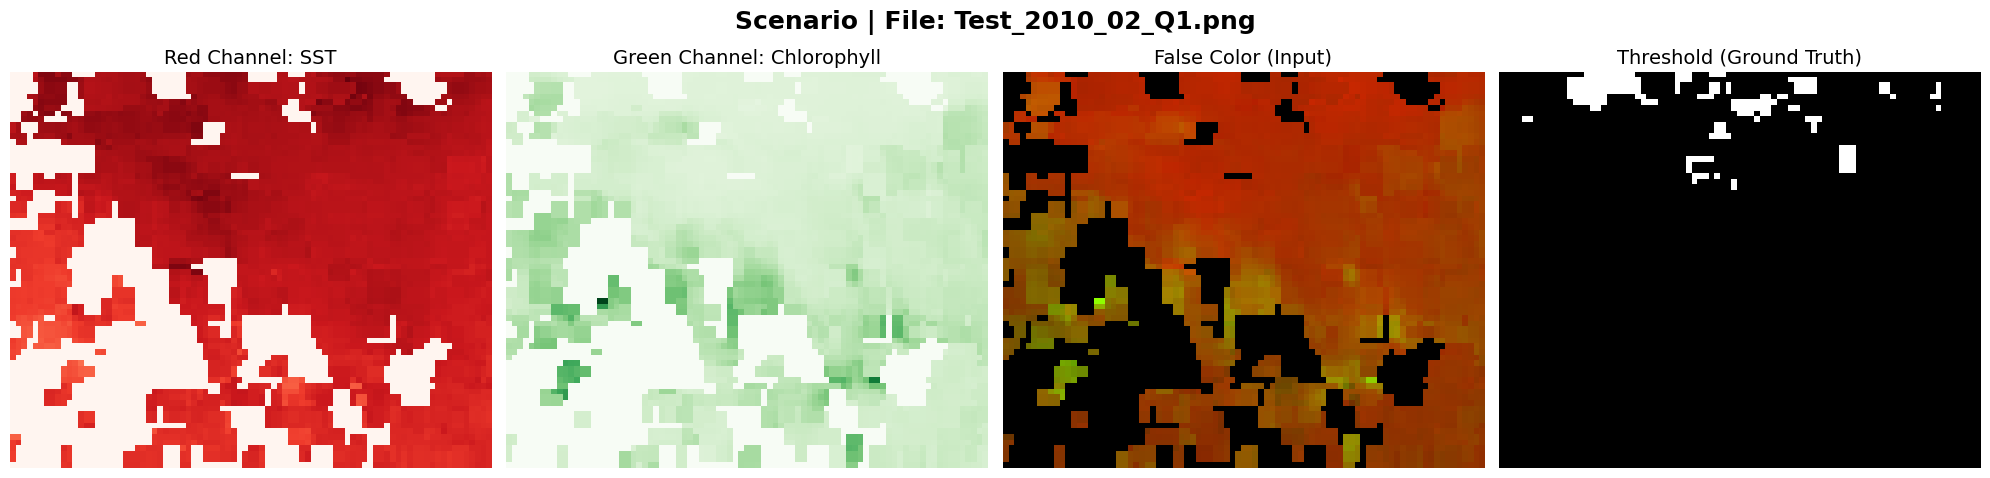

✅ Successfully saved as: inputs_con_dano.png


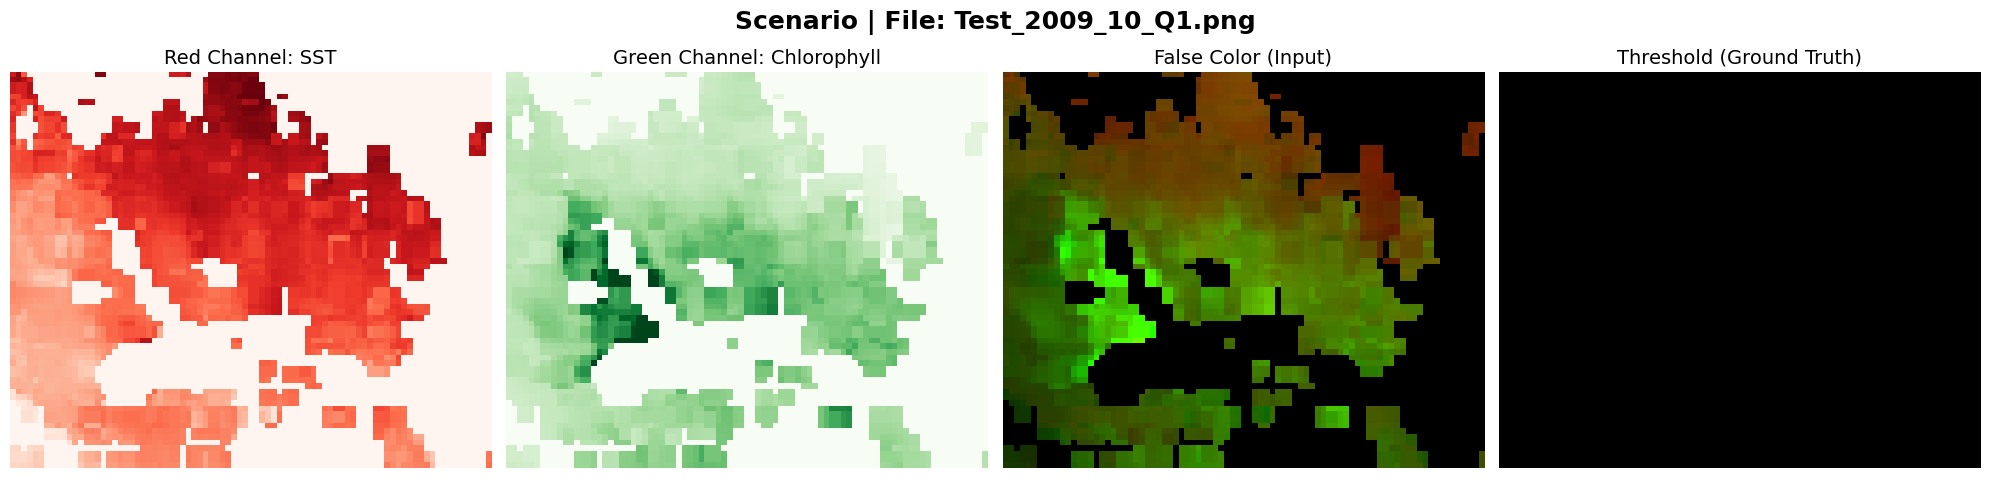

✅ Successfully saved as: inputs_sin_dano.png


In [19]:
import os
import cv2
import matplotlib.pyplot as plt

# ==========================================
# 1. MANUAL CONFIGURATION
# ==========================================
DIR_TEST_IMG = 'ML_Dataset/test/images'
DIR_TEST_MSK = 'ML_Dataset/test/masks'

# Write the EXACT names of the files you want to use here:
archivo_con_dano = 'Test_2010_02_Q1.png' # Replace with your El Niño representative image
archivo_sin_dano = 'Test_2009_10_Q1.png' # Replace with your normal conditions representative image

# ==========================================
# 2. GENERATOR FUNCTION
# ==========================================
def generar_grupo_inputs(nombre_archivo, titulo_escenario, nombre_salida):
    ruta_img = os.path.join(DIR_TEST_IMG, nombre_archivo)
    ruta_msk = os.path.join(DIR_TEST_MSK, nombre_archivo)
    
    # Safegaurd for missing files
    if not os.path.exists(ruta_img) or not os.path.exists(ruta_msk):
        print(f"❌ ERROR: Could not find image or mask for '{nombre_archivo}'. Please check the name.")
        return
    
    # Load image and separate channels
    img_bgr = cv2.imread(ruta_img)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    canal_r = img_rgb[:, :, 0] # SST
    canal_g = img_rgb[:, :, 1] # Chlorophyll
    
    # Load deterministic mask
    mask = cv2.imread(ruta_msk, cv2.IMREAD_GRAYSCALE)
    
    # Create the figure (1 row, 4 columns)
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(f'{titulo_escenario} | File: {nombre_archivo}', fontsize=18, fontweight='bold')
    
    # 1. Red Channel
    axes[0].imshow(canal_r, cmap='Reds')
    axes[0].set_title('Red Channel: SST', fontsize=14)
    axes[0].axis('off')
    
    # 2. Green Channel
    axes[1].imshow(canal_g, cmap='Greens')
    axes[1].set_title('Green Channel: Chlorophyll', fontsize=14)
    axes[1].axis('off')
    
    # 3. False Color
    axes[2].imshow(img_rgb)
    axes[2].set_title('False Color (Input)', fontsize=14)
    axes[2].axis('off')
    
    # 4. Threshold (Ground Truth)
    axes[3].imshow(mask, cmap='gray')
    axes[3].set_title('Threshold (Ground Truth)', fontsize=14)
    axes[3].axis('off')
    
    plt.tight_layout()
    plt.savefig(nombre_salida, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Successfully saved as: {nombre_salida}")

# ==========================================
# 3. EXECUTION
# ==========================================
print("Generating images for the paper...")
generar_grupo_inputs(archivo_con_dano, "Scenario", "inputs_con_dano.png")
generar_grupo_inputs(archivo_sin_dano, "Scenario", "inputs_sin_dano.png")